In [273]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

In [3]:
'/Volumes/data_ssd3/Barber_Lab/data/20260602_TEM_HPF/ponA_mg_A3805/ponA_mg_10kX_0002.tif'

'/Volumes/data_ssd3/Barber_Lab/data/20260602_TEM_HPF/ponA_mg_A3805/ponA_mg_10kX_0002.tif'

In [4]:
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
cond="/ponA_mg_A3805"
im="ponA_mg_10kX_0002"
im1=io.imread(base_path+expt_id+cond+'/'+im+'.tif')

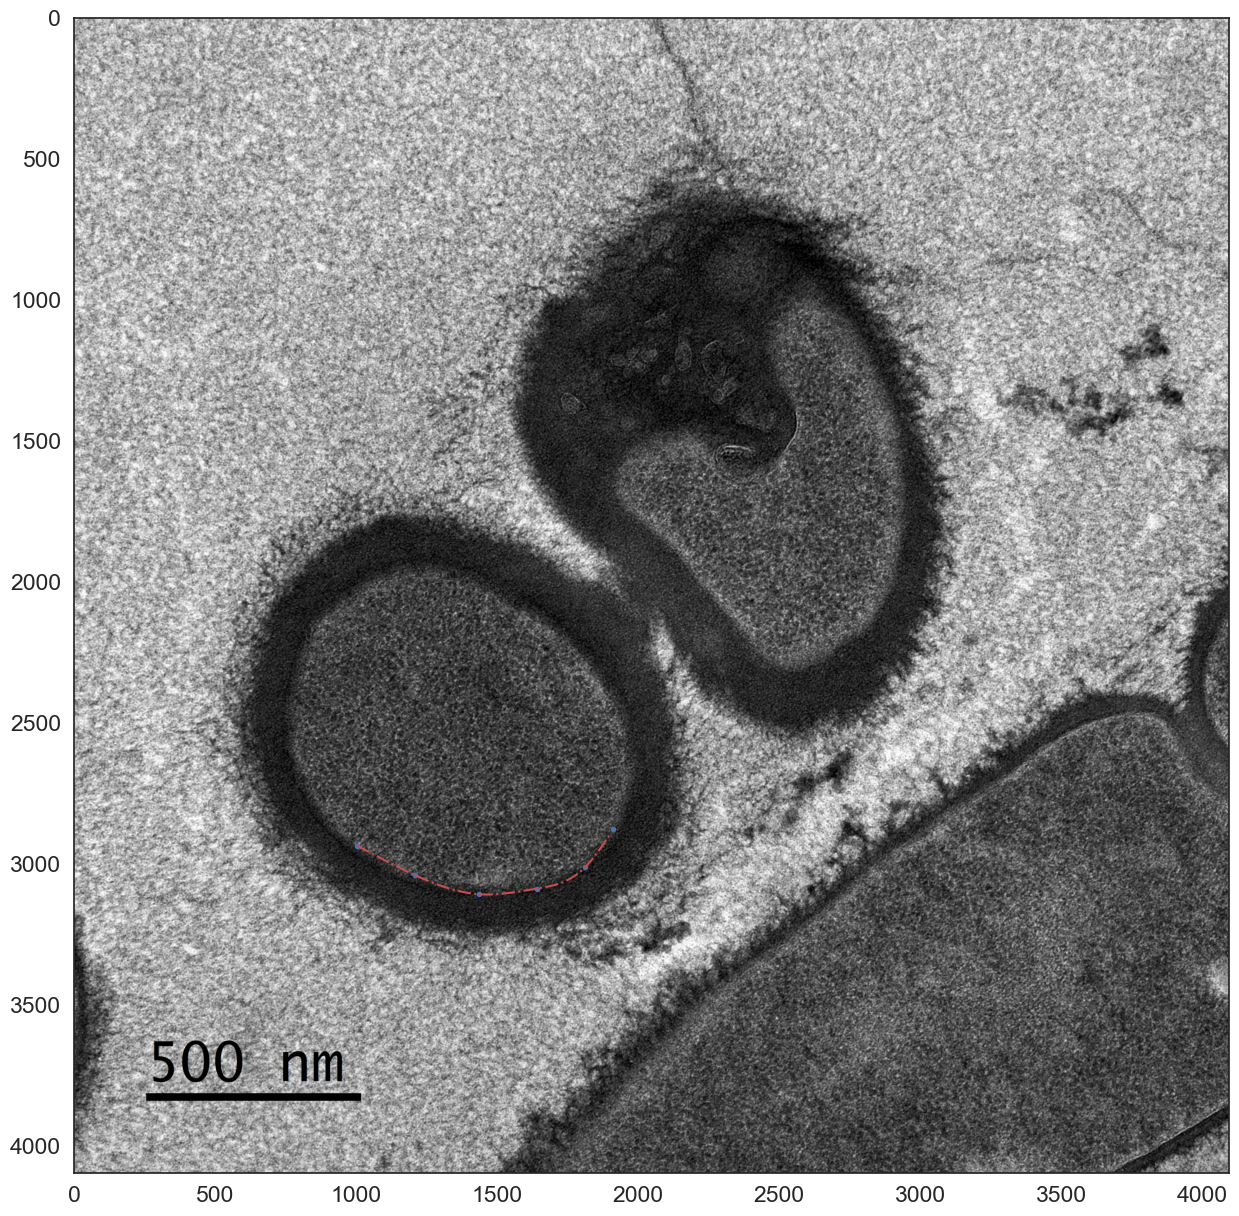

In [104]:
coords=pd.read_csv(base_path+expt_id+'/saved_contours'+cond+'/'+im+'/'+im+'_cell_1.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[15,15])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/100)
plt.plot(xnew, spl(xnew), '-.', label=fr'$\lambda=${lam}',color='r')

Okay, so this contour looks fine as does the spline. Let's find the normal lines at various points along the spline. Note that the fact that we are specifying "clockwise" for point annotation basically means that if x is increasing, we want the direction in which y increases, while if x is decreasing, we want the direction in which y decreases.

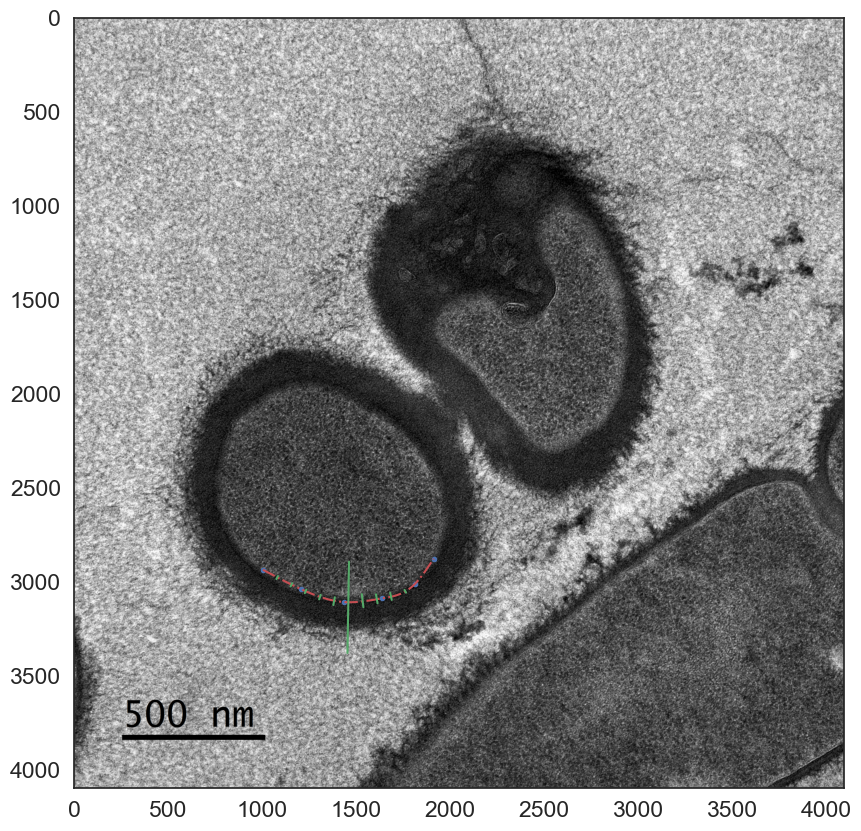

In [108]:
coords=pd.read_csv(base_path+expt_id+'/saved_contours'+cond+'/'+im+'/'+im+'_cell_1.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[10,10])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
num_fits=10
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/(num_fits+2))[1:-1]
xnew1 = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/1000)
ynew1=spl(xnew1)
plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
window=5
for ind in np.arange(len(xnew)):
    point=np.nonzero(xnew1>xnew[ind])[0][0]
    slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
    temp_xv=xnew1[point-window:point+window]
    temp_yv=float(spl(xnew1[point]))-1.0/slope[0]*(temp_xv-xnew1[point])
    plt.plot(temp_xv,temp_yv,'-',color='g')

This looks like we're capturing the right behaviour. Now, let's figure out how to extract useful values. Slope +ve and xf-xi>0 —> incr. x. Slope -ve and xf-xi>0 -> decr. x. Slope +ve and xf-xi<0 -> decr. x. Slope -ve and xf-xi<0 -> incr. x. We will extract intensity values out to 200nm.

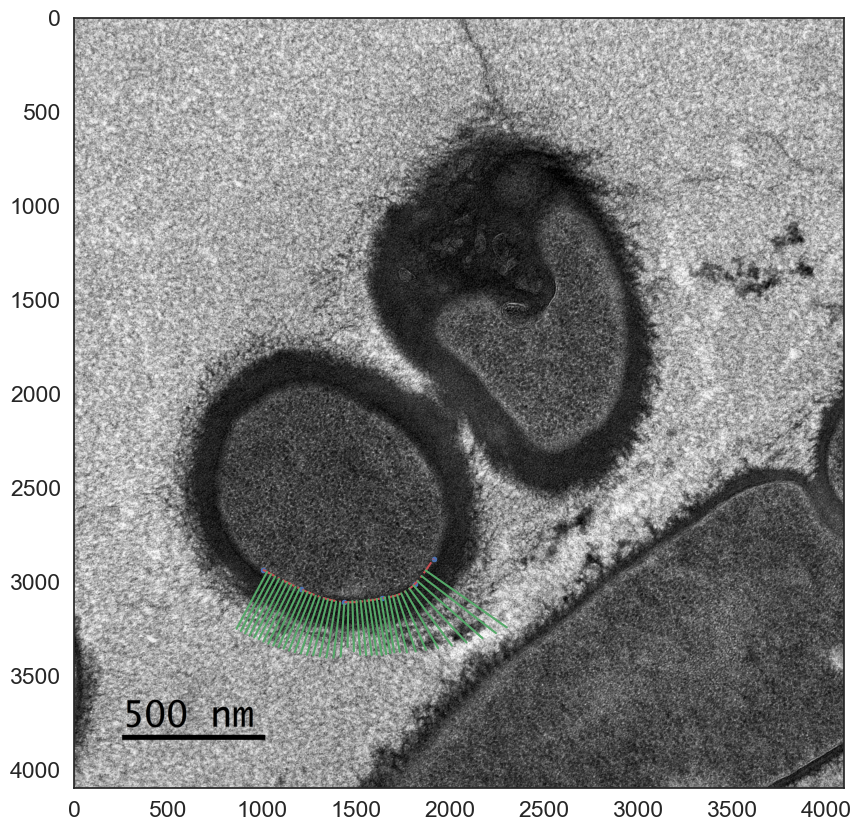

In [109]:
coords=pd.read_csv(base_path+expt_id+'/saved_contours'+cond+'/'+im+'/'+im+'_cell_1.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[10,10])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
num_fits=40
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/(num_fits+2))[1:-1]
xnew1 = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/1000)
ynew1=spl(xnew1)
plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
window=5
scale=500.0/762.0 # nm/pixel.
depth=200
for ind in np.arange(len(xnew)):
    point=np.nonzero(xnew1>xnew[ind])[0][0]
    slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
    num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
    if (xv[-1]-xv[0])>0 and slope[0]>0:
        xrange=np.arange(xnew[ind],xnew[ind]+num_points,1)
    elif (xv[-1]-xv[0])>0 and slope[0]<0:
        xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
    elif (xv[-1]-xv[0])<0 and slope[0]>0:
        xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
    elif (xv[-1]-xv[0])<0 and slope[0]<0:
        xrange=np.arange(xnew[ind],xnew[ind]+num_points,+1)
    # print(slope[0])
    yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
        # now let's plot
    plt.plot(xrange,yrange,'-',color='g')
    

This seems to be working well! Now, let's figure out unit-spaced points along those lines and extract the pixel intensity values at those points.

In [152]:
im2[xcoords.astype(int),ycoords.astype(int)]

array([ 89,  94,  88,  88,  84,  77,  83,  79,  95,  99,  91,  94,  76,
        56,  50,  50,  51,  55,  65,  72,  86,  80,  80,  76,  76,  78,
        78,  74,  67,  69,  64,  63,  63,  72,  88,  86,  86,  74,  71,
        68,  53,  59,  57,  52,  52,  51,  58,  74,  77,  97, 114, 111,
       111,  79,  74,  71,  73,  66,  68,  77,  76,  80,  70,  57,  57,
        54,  61,  72,  72,  76,  63,  66,  75,  75,  90, 100, 106, 112,
       101, 104,  83,  83,  74,  53,  57,  55,  54,  55,  67,  85,  89,
       116, 102, 102,  68,  49,  39,  40,  53,  59,  64,  64,  70,  66,
        61,  61,  65,  64,  55,  48,  48,  39,  42,  43,  52,  68,  80,
       108, 118, 113, 113, 100, 100,  99,  99,  98,  96,  85,  83,  69,
        74,  67,  64,  55,  55,  57,  63,  72,  83,  91,  88,  86,  86,
        65,  68,  63,  69,  84,  99, 125, 139, 139, 131, 111,  90,  96,
        77,  74,  75,  79,  69,  64,  57,  57,  60,  65,  69,  58,  67,
        64,  75,  75,  86,  99, 101, 108, 103, 107, 111, 102, 12

In [149]:
im2[list(zip(list(xcoords.astype(int)),list(ycoords.astype(int))))]

array([[[137, 154, 166, ...,  92,  78,  66],
        [233, 228, 201, ...,  57,  58,  65]],

       [[138, 151, 159, ...,  87,  81,  70],
        [213, 194, 185, ...,  70,  71,  76]],

       [[149, 155, 161, ...,  79,  74,  73],
        [179, 169, 165, ...,  73,  77,  78]],

       ...,

       [[164, 165, 145, ..., 103,  92,  86],
        [227, 225, 228, ...,  61,  64,  84]],

       [[162, 162, 157, ..., 114, 111,  97],
        [206, 205, 215, ...,  58,  71,  96]],

       [[161, 152, 147, ..., 123, 118, 110],
        [194, 195, 205, ...,  57,  70,  93]]],
      shape=(200, 2, 4096), dtype=uint8)

In [145]:
im2=im1[:,:,0]

In [147]:
im2[list(zip(list(xcoords),list(ycoords)))]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [128]:
im1[np.nonzero(xcoords)[0],np.nonzero(ycoords)[0]]

array([[168, 168, 168],
       [171, 171, 171],
       [180, 180, 180],
       [205, 205, 205],
       [207, 207, 207],
       [209, 209, 209],
       [220, 220, 220],
       [208, 208, 208],
       [193, 193, 193],
       [183, 183, 183],
       [173, 173, 173],
       [173, 173, 173],
       [173, 173, 173],
       [194, 194, 194],
       [206, 206, 206],
       [190, 190, 190],
       [168, 168, 168],
       [163, 163, 163],
       [145, 145, 145],
       [139, 139, 139],
       [131, 131, 131],
       [132, 132, 132],
       [139, 139, 139],
       [139, 139, 139],
       [144, 144, 144],
       [146, 146, 146],
       [149, 149, 149],
       [166, 166, 166],
       [172, 172, 172],
       [165, 165, 165],
       [164, 164, 164],
       [158, 158, 158],
       [144, 144, 144],
       [141, 141, 141],
       [149, 149, 149],
       [174, 174, 174],
       [193, 193, 193],
       [179, 179, 179],
       [151, 151, 151],
       [122, 122, 122],
       [123, 123, 123],
       [144, 144

In [123]:
zip(*[xcoords,ycoords])

In [122]:
xcoords

array([1845.61904762, 1846.3749554 , 1847.13086318, 1847.88677096,
       1848.64267875, 1849.39858653, 1850.15449431, 1850.91040209,
       1851.66630987, 1852.42221766, 1853.17812544, 1853.93403322,
       1854.689941  , 1855.44584878, 1856.20175656, 1856.95766435,
       1857.71357213, 1858.46947991, 1859.22538769, 1859.98129547,
       1860.73720325, 1861.49311104, 1862.24901882, 1863.0049266 ,
       1863.76083438, 1864.51674216, 1865.27264995, 1866.02855773,
       1866.78446551, 1867.54037329, 1868.29628107, 1869.05218885,
       1869.80809664, 1870.56400442, 1871.3199122 , 1872.07581998,
       1872.83172776, 1873.58763555, 1874.34354333, 1875.09945111,
       1875.85535889, 1876.61126667, 1877.36717445, 1878.12308224,
       1878.87899002, 1879.6348978 , 1880.39080558, 1881.14671336,
       1881.90262115, 1882.65852893, 1883.41443671, 1884.17034449,
       1884.92625227, 1885.68216005, 1886.43806784, 1887.19397562,
       1887.9498834 , 1888.70579118, 1889.46169896, 1890.21760

In [173]:
len(im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])

200

In [174]:
    intensity_vals.shape

(40, 457)

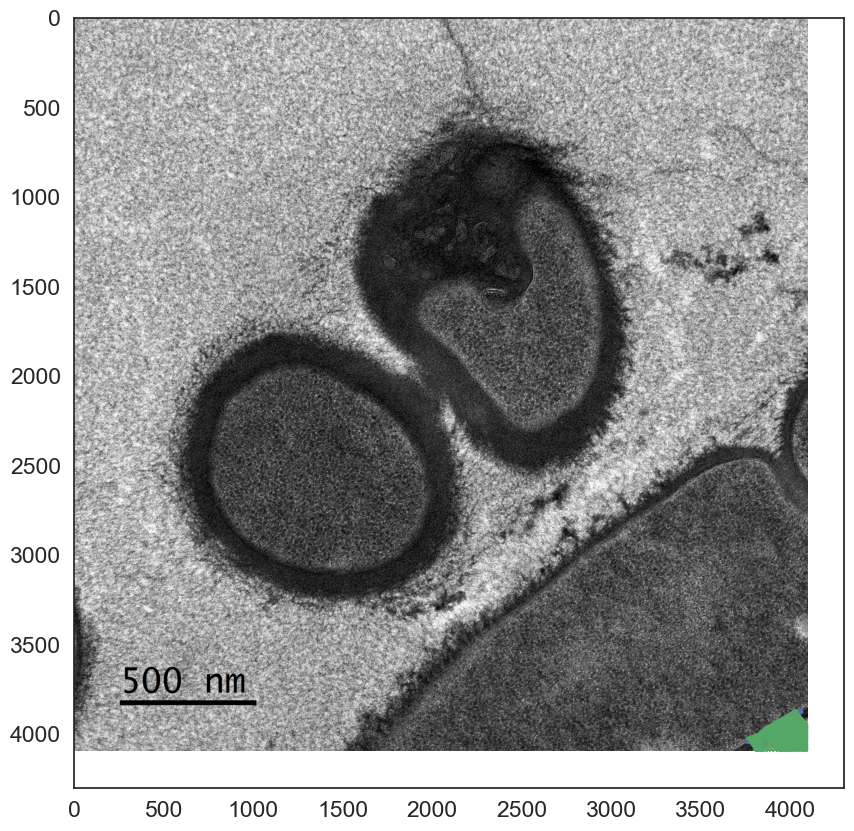

In [277]:
coords=pd.read_csv(base_path+expt_id+'/saved_contours'+cond+'/'+im+'/'+im+'_cell_1.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[10,10])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
num_fits=40
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/(num_fits+2))[1:-1]
xnew1 = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/1000)
ynew1=spl(xnew1)
plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
window=5
scale=500.0/762.0 # nm/pixel.
depth=300
opp_depth=20 # distance to backtrack — allows you to precisely measure the position of the membrane
intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
im2=im1[:,:,0]

for ind in np.arange(len(xnew)):
    point=np.nonzero(xnew1>xnew[ind])[0][0]
    slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
    num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
    xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
    yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
    # now let's unit-spaced coordinates along this line, from start to end.
    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
    sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
    plt.plot(xcoords[sel_vals],ycoords[sel_vals],'-',color='g')
    intensity_vals[ind,sel_vals]=(255.0-im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])/255.0

In [280]:
opp_depth*scale

13.123359580052494

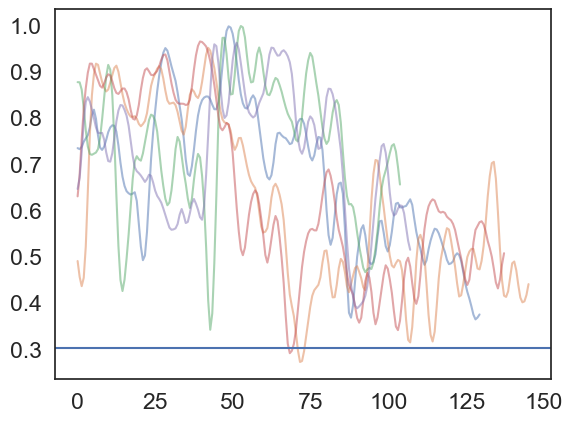

In [279]:
ints=np.random.randint(low=0,high=intensity_vals.shape[0]-1,size=5)
x=scale*np.arange(intensity_vals.shape[1])
for int_temp in ints:
    plt.plot(x,skimage.filters.gaussian(intensity_vals[int_temp,:]),alpha=0.5)
background=(255.0-np.mean(im2[:1000,:1000].flatten()))/255.0
plt.axhline(background)
# plt.fill_between(np.n

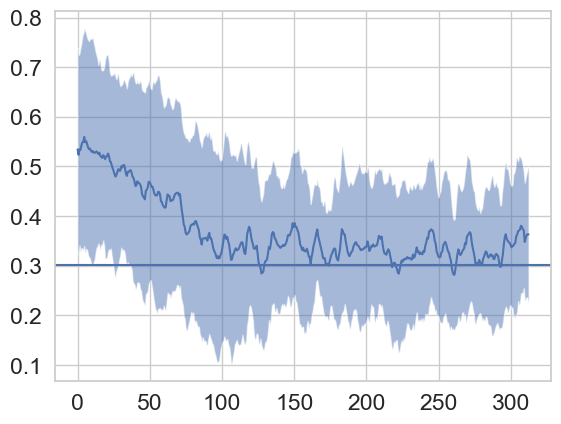

In [276]:
x=scale*np.arange(intensity_vals.shape[1])
plt.plot(x,np.nanmean(intensity_vals,axis=0))
plt.fill_between(x,np.nanmean(intensity_vals,axis=0)+np.nanstd(intensity_vals,axis=0),np.nanmean(intensity_vals,axis=0)-np.nanstd(intensity_vals,axis=0),alpha=0.5)
background=(255.0-np.mean(im2[:1000,:1000].flatten()))/255.0
plt.axhline(background)
# plt.fill_between(np.n

Okay, this I think is actually pretty helpful! I think there's going to be some reasonable questions about where to draw the line here, but for now one approach is "the minimal value after which the next lowest point is <5% below where we are now" to account for noise.

In [197]:
intensity_vals

array([[0.76078431, 0.74509804, 0.72941176, ...,        nan,        nan,
               nan],
       [0.78039216, 0.80784314, 0.80784314, ...,        nan,        nan,
               nan],
       [0.81568627, 0.81568627, 0.79607843, ...,        nan,        nan,
               nan],
       ...,
       [0.90196078, 0.89411765, 0.92156863, ...,        nan,        nan,
               nan],
       [0.88627451, 0.8745098 , 0.8745098 , ...,        nan,        nan,
               nan],
       [0.83529412, 0.80784314, 0.68627451, ...,        nan,        nan,
               nan]], shape=(40, 457))

In [209]:
np.transpose(np.array([np.nanmin(array[:,ind:],axis=1) for ind in np.arange(array.shape[1])]))

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_42248/3319452638.py:1: RuntimeWarning: All-NaN slice encountered
  np.transpose(np.array([np.nanmin(array[:,ind:],axis=1) for ind in np.arange(array.shape[1])]))


array([[0.54901961, 0.54901961, 0.54901961, ...,        nan,        nan,
               nan],
       [0.6       , 0.6       , 0.6       , ...,        nan,        nan,
               nan],
       [0.45098039, 0.45098039, 0.45098039, ...,        nan,        nan,
               nan],
       ...,
       [0.23921569, 0.23921569, 0.23921569, ...,        nan,        nan,
               nan],
       [0.25098039, 0.25098039, 0.25098039, ...,        nan,        nan,
               nan],
       [0.34509804, 0.34509804, 0.34509804, ...,        nan,        nan,
               nan]], shape=(40, 457))

In [217]:
np.nanmin(array[:,:10],axis=1)

array([0.68627451, 0.77647059, 0.71764706, 0.58431373, 0.61568627,
       0.61568627, 0.70196078, 0.67058824, 0.58431373, 0.7254902 ,
       0.66666667, 0.65882353, 0.50196078, 0.76862745, 0.47058824,
       0.68627451, 0.52156863, 0.47843137, 0.45882353, 0.57647059,
       0.63529412, 0.50980392, 0.64705882, 0.41176471, 0.39607843,
       0.6       , 0.80784314, 0.81176471, 0.85490196, 0.82745098,
       0.78039216, 0.74117647, 0.78039216, 0.88627451, 0.83137255,
       0.83137255, 0.85490196, 0.88235294, 0.77254902, 0.63137255])

In [239]:
ind

np.int64(39)

In [258]:
np.nonzero(min_vals<1.1*glob_mins[i0])

(array([0]), array([3]))

In [251]:
glob_mins=np.nanmin(array,axis=1)
mins=scipy.signal.argrelmin(array[i0,:ind])
min_vals=array[i0,mins]
min_vals1=mins[np.nonzero(min_vals<1.1*glob_mins[i0])[0][0]]


In [252]:
min_vals

array([[0.72941176, 0.71372549, 0.70588235, 0.59607843, 0.72156863,
        0.64705882]])

In [253]:
glob_mins[i0]

np.float64(0.5490196078431373)

In [249]:
mins

(array([ 2, 11, 13, 27, 34, 37]),)

In [250]:
min_vals

array([ 2, 11, 13, 27, 34, 37])

In [237]:
i0=0
min_arr=[np.nanmin(array[i0,:ind]) for ind in np.arange(1,array.shape[1])]
min_val=[np.nonzero((min_arr<1.1*np.amin(min_arr[ind,:]))*(ind in scipy.signal.argrelmin(array[i0,:ind])))]

TypeError: list indices must be integers or slices, not tuple

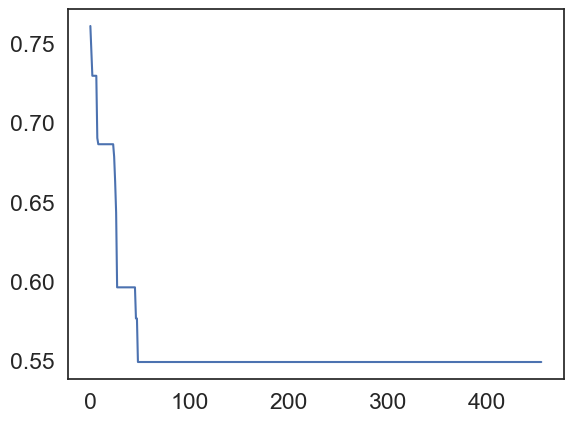

In [236]:
plt.plot(min_arr)

In [222]:
from scipy.signal import find_peaks

In [227]:
find_peaks(1-array[0,:],prominence=1)

(array([], dtype=int64),
 {'prominences': array([], dtype=float64),
  'left_bases': array([], dtype=int64),
  'right_bases': array([], dtype=int64)})

In [229]:
scipy.signal.argrelmin(array[0,:])

(array([ 2, 11, 13, 27, 34, 37, 46, 48, 55, 57, 61, 64]),)

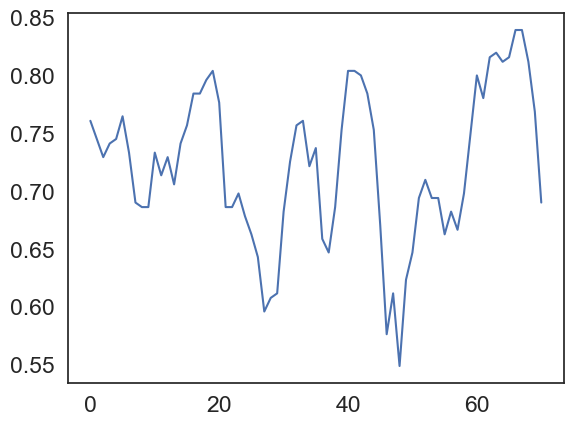

In [221]:
plt.plot(array[0,:])

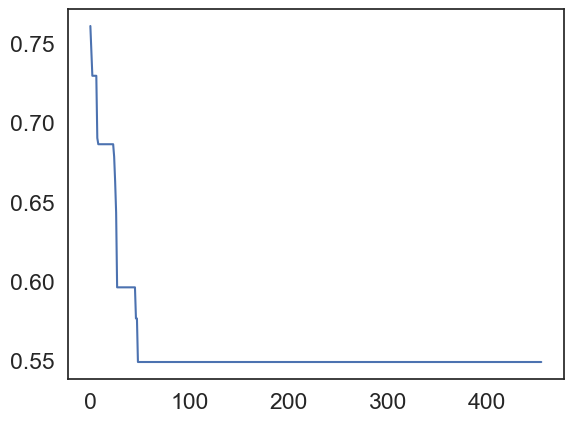

In [218]:
array=intensity_vals.copy()
plt.plot(np.transpose(np.array([np.nanmin(array[:,:ind],axis=1) for ind in np.arange(1,array.shape[1])]))[0,:])

In [ ]:
def min_finder(array):
    # for each trace, let's calculate the minimal spacing, then we'll take the median value for the cell overall.
    for ind in range(
    np.transpose(np.array([np.amin(array[:,ind:],axis=1) for ind in np.arange(array.shape[1])])